# Chatbots and Dialogue Systems

**Gudsky Research Foundation  |  Research Intake 2026  |  Day 25**
*Module: Chatbots and Dialogue*

This notebook implements the core components of a task-oriented dialogue system and a
generative dialogue agent, following the pipeline described in the Day 25 compendium.

**Sections**

1. Environment setup
2. Intent classification (zero-shot NLI and fine-tuned BERT)
3. Slot filling with BIO sequence labelling
4. Retrieval-based response selection (SBERT + FAISS)
5. Generative dialogue with DialoGPT
6. Evaluation: BERTScore for dialogue response quality

**Runtime:** Set `Runtime > Change runtime type > Hardware accelerator > T4 GPU`.


## 1  Environment Setup

In [1]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print("No GPU detected. Sections 2-5 will be slower on CPU.")


GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
!pip uninstall -y -q huggingface_hub
!pip install -q "huggingface_hub>=0.34.0,<1.0"
!pip install -q -U transformers datasets accelerate
!pip install -q sentence-transformers faiss-cpu bert-score
!pip install -q scikit-learn matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 9.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.13.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.2 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           AutoModelForTokenClassification, AutoModelForCausalLM,
                           TrainingArguments, Trainer, DataCollatorWithPadding,
                           DataCollatorForTokenClassification, pipeline)
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sentence_transformers import SentenceTransformer
import faiss

def make_training_args(**kwargs):
    '''Build TrainingArguments handling the eval_strategy / evaluation_strategy rename
    across transformers versions.'''
    strategy = kwargs.pop("eval_strategy", "epoch")
    try:
        return TrainingArguments(eval_strategy=strategy, **kwargs)
    except TypeError:
        return TrainingArguments(evaluation_strategy=strategy, **kwargs)

print("Imports complete.")


Imports complete.


## 2  Intent Classification

Intent classification labels each user utterance with its communicative goal.
We demonstrate two approaches:

1. **Zero-shot classification via NLI** (no training data required) -- uses a pre-trained
   NLI model to score the probability that a given utterance entails each candidate intent label.

2. **Supervised BERT fine-tuning** -- fine-tunes BERT on the BANKING77 intent classification
   dataset, which contains 13,083 customer service utterances across 77 banking intents.


In [7]:
from datasets import load_dataset, Dataset, DatasetDict, ClassLabel, Features, Value
import pandas as pd

INTENT_NAMES = [
    "activate_my_card", "age_limit", "apple_pay_or_google_pay", "atm_support",
    "automatic_top_up", "balance_not_updated_after_bank_transfer",
    "balance_not_updated_after_cheque_or_cash_deposit", "beneficiary_not_allowed",
    "cancel_transfer", "card_about_to_expire", "card_acceptance",
    "card_arrival", "card_delivery_estimate", "card_linking", "card_not_working",
    "card_payment_fee_charged", "card_payment_not_recognised",
    "card_payment_wrong_exchange_rate", "card_swallowed", "cash_withdrawal_charge",
    "cash_withdrawal_not_recognised", "change_pin", "compromised_card",
    "contactless_not_working", "country_support", "declined_card_payment",
    "declined_cash_withdrawal", "declined_transfer", "direct_debit_payment_not_recognised",
    "disposable_card_limits", "edit_personal_details", "exchange_charge",
    "exchange_rate", "exchange_via_app", "extra_charge_on_statement",
    "failed_transfer", "fiat_currency_support", "get_disposable_virtual_card",
    "get_physical_card", "getting_spare_card", "getting_virtual_card",
    "lost_or_stolen_card", "lost_or_stolen_phone", "order_physical_card",
    "passcode_forgotten", "pending_card_payment", "pending_cash_withdrawal",
    "pending_top_up", "pending_transfer", "pin_blocked", "receiving_money",
    "refund_not_showing_up", "request_refund", "reverted_card_payment",
    "sending_money", "share_balance", "sharing_personal_information",
    "supported_cards_and_currencies", "terminate_account", "top_up_by_bank_transfer_charge",
    "top_up_by_card_charge", "top_up_by_cash_or_cheque", "top_up_failed",
    "top_up_limits", "top_up_reverted", "topping_up_by_card",
    "transaction_charged_twice", "transfer_fee_charged", "transfer_into_account",
    "transfer_not_received_by_recipient", "transfer_timing", "unable_to_verify_identity",
    "verify_my_identity", "verify_source_of_funds", "verify_top_up",
    "virtual_card_not_working", "visa_or_mastercard", "why_verify_identity",
    "wrong_amount_of_cash_received", "wrong_exchange_rate_for_cash_withdrawal",
]

try:
    base = ("https://huggingface.co/datasets/PolyAI/banking77/resolve/refs"
            "/convert/parquet/default/")
    banking = load_dataset("parquet", data_files={
        "train": base + "train/0000.parquet",
        "test":  base + "test/0000.parquet",
    })
    print("Loaded via Parquet.")
except Exception as e:
    print(f"Network load failed ({e}). Building synthetic dataset...")
    # Build a small synthetic dataset covering the first 20 intents
    import random
    random.seed(42)
    templates = [
        "I need help with {intent}.",
        "Can you assist me with {intent}?",
        "I have a question about {intent}.",
        "There is an issue with {intent}.",
        "How do I resolve {intent}?",
    ]
    rows_train, rows_test = [], []
    for label, name in enumerate(INTENT_NAMES[:20]):
        readable = name.replace("_", " ")
        for t in templates:
            rows_train.append({"text": t.format(intent=readable), "label": label})
        rows_test.append({"text": f"Help me with {readable}.", "label": label})
    banking = DatasetDict({
        "train": Dataset.from_list(rows_train),
        "test":  Dataset.from_list(rows_test),
    })
    print("Synthetic fallback dataset built.")

print(banking)
print()

# Safely retrieve intent names from the dataset or fall back to our list
try:
    intent_names = banking["train"].features["label"].names
except Exception:
    intent_names = INTENT_NAMES

n_classes = len(set(banking["train"]["label"]))
print(f"Number of intent classes: {n_classes}")
print(f"Sample intents: {intent_names[:8]} ...")
print()
for i in range(4):
    ex = banking["train"][i]
    label_name = intent_names[ex["label"]] if ex["label"] < len(intent_names) else str(ex["label"])
    print(f"  [{label_name}]  {ex['text']}")

Network load failed (datasets/PolyAI/banking77@refs/convert/parquet/default/train/0000.parquet (revision not found)). Building synthetic dataset...
Synthetic fallback dataset built.
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 100
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 20
    })
})

Number of intent classes: 20
Sample intents: ['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up', 'balance_not_updated_after_bank_transfer', 'balance_not_updated_after_cheque_or_cash_deposit', 'beneficiary_not_allowed'] ...

  [activate_my_card]  I need help with activate my card.
  [activate_my_card]  Can you assist me with activate my card?
  [activate_my_card]  I have a question about activate my card.
  [activate_my_card]  There is an issue with activate my card.


In [8]:
# Zero-shot intent classification via NLI.
# For each utterance, we test whether it entails each candidate intent description.
# This requires no labelled training data.

nli_pipe = pipeline("zero-shot-classification",
                    model="facebook/bart-large-mnli",
                    device=0 if torch.cuda.is_available() else -1)

def classify_intent_zero_shot(utterance, candidate_intents):
    '''Classify an utterance into one of the candidate intent categories using NLI.

    Parameters
    ----------
    utterance : str
        The raw user utterance to classify.
    candidate_intents : list of str
        Candidate intent labels expressed as natural language descriptions.
        These are passed as hypothesis labels to the NLI model.

    Returns
    -------
    str
        The predicted intent label (highest entailment probability).
    float
        The confidence score for the predicted label.
    '''
    result = nli_pipe(utterance, candidate_labels=candidate_intents, multi_label=False)
    return result["labels"][0], result["scores"][0]

# Demonstrate on a small set of intents (zero-shot works best when intents are
# expressed as self-descriptive natural-language phrases)
demo_intents = [
    "check account balance",
    "report lost or stolen card",
    "dispute a transaction",
    "change PIN",
    "international transfer",
    "apply for a loan",
]

test_utterances = [
    "What is my current balance?",
    "I think someone has stolen my card.",
    "A charge appeared on my statement that I don't recognise.",
    "I need to set a new PIN for my card.",
    "I want to send money to my family abroad.",
]

print(f"{'Utterance':<50}  {'Predicted Intent':<25}  Conf")
print("-" * 85)
for utt in test_utterances:
    pred, conf = classify_intent_zero_shot(utt, demo_intents)
    print(f"{utt:<50}  {pred:<25}  {conf:.3f}")


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Utterance                                           Predicted Intent           Conf
-------------------------------------------------------------------------------------
What is my current balance?                         change PIN                 0.365
I think someone has stolen my card.                 report lost or stolen card  0.543
A charge appeared on my statement that I don't recognise.  dispute a transaction      0.420
I need to set a new PIN for my card.                change PIN                 0.887
I want to send money to my family abroad.           international transfer     0.644


In [9]:
# Supervised intent classification: fine-tune BERT on BANKING77.
# We use a representative subset of intents for speed (first 20 of 77).
# The same procedure scales to all 77 intents.

SUBSET_INTENTS = 20    # number of intent classes to include
INTENT_MODEL   = "bert-base-uncased"

# Filter to examples belonging to the first SUBSET_INTENTS classes
def filter_subset(dataset, n_classes):
    return dataset.filter(lambda ex: ex["label"] < n_classes)

banking_sub = {
    "train": filter_subset(banking["train"], SUBSET_INTENTS),
    "test":  filter_subset(banking["test"],  SUBSET_INTENTS),
}

print(f"Subset: {SUBSET_INTENTS} intents, "
      f"{len(banking_sub['train'])} train / {len(banking_sub['test'])} test examples")

intent_tokenizer = AutoTokenizer.from_pretrained(INTENT_MODEL)

def tokenize_intent(batch):
    return intent_tokenizer(
        batch["text"],
        truncation=True,
        max_length=64,     # customer service utterances are typically short
    )

tok_banking = {
    split: ds.map(tokenize_intent, batched=True).remove_columns(["text"]).with_format("torch")
    for split, ds in banking_sub.items()
}

intent_collator = DataCollatorWithPadding(tokenizer=intent_tokenizer)
print("BANKING77 subset tokenised.")


Filter:   0%|          | 0/100 [00:00<?, ? examples/s]

Filter:   0%|          | 0/20 [00:00<?, ? examples/s]

Subset: 20 intents, 100 train / 20 test examples


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

BANKING77 subset tokenised.


In [10]:
def compute_metrics_intent(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "macro_f1":  f1_score(labels, preds, average="macro"),
    }

intent_model = AutoModelForSequenceClassification.from_pretrained(
    INTENT_MODEL,
    num_labels=SUBSET_INTENTS,
).to(device)

intent_args = make_training_args(
    output_dir                  = "./bert_intent",
    num_train_epochs            = 5,       # intent classification benefits from more epochs
    learning_rate               = 3e-5,    # slightly higher than standard: smaller dataset
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "macro_f1",
    fp16                        = torch.cuda.is_available(),
    report_to                   = [],
)

intent_trainer = Trainer(
    model           = intent_model,
    args            = intent_args,
    train_dataset   = tok_banking["train"],
    eval_dataset    = tok_banking["test"],
    data_collator   = intent_collator,
    compute_metrics = compute_metrics_intent,
)

intent_trainer.train()
print("Intent classifier training complete.")


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,3.012402,0.050000,0.004762
2,No log,2.853809,0.100000,0.021978
3,No log,2.791846,0.050000,0.005263
4,No log,2.716553,0.100000,0.018182
5,No log,2.696289,0.100000,0.019444


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Intent classifier training complete.


In [11]:
intent_results = intent_trainer.evaluate(tok_banking["test"])
print(f"BERT intent classifier ({SUBSET_INTENTS} classes, BANKING77 subset)")
print(f"  Accuracy  : {intent_results['eval_accuracy']:.4f}")
print(f"  Macro F1  : {intent_results['eval_macro_f1']:.4f}")


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
No log,2.852637,5,0.150000,0.076667


BERT intent classifier (20 classes, BANKING77 subset)
  Accuracy  : 0.1500
  Macro F1  : 0.0767


## 3  Slot Filling with BIO Sequence Labelling

Slot filling extracts named parameter values from an utterance.  It is modelled as a sequence
labelling task, where each token receives a BIO tag:

- **B-SLOT**: beginning of a slot value span
- **I-SLOT**: inside (continuation) of a slot value span
- **O**: outside any slot

For example, for the utterance "Book a flight from London to Paris on Friday":

    Token:   Book  a     flight  from  London  to    Paris  on    Friday
    Label:   O     O     O       O     B-DEP   O     B-DST  O     B-DATE

We demonstrate BIO tagging using the MultiNERD dataset and a BERT token classifier.
MultiNERD contains named entity annotations (person, location, organisation, etc.)
which serve as a proxy for the slot-filling BIO task; the same architecture applies
directly to domain-specific slot schemas.


In [19]:
from datasets import load_dataset, ClassLabel, Sequence

# MultiNERD is a multilingual NER dataset. We use the English subset.
# NER token classification is structurally identical to slot filling:
# both are BIO sequence labelling tasks on the same token classifier architecture.

# Load from the auto-converted Parquet branch — the main branch uses a loading
# script that's no longer supported, and its split-size metadata is also broken.
multinerd = load_dataset("Babelscape/multinerd", revision="refs/convert/parquet")

# Keep only English examples
multinerd_en = multinerd.filter(lambda ex: ex["lang"] == "en")

# Parquet conversion flattens ClassLabel -> plain int, so .names isn't available.
# Hardcode the tagset from the dataset card (15 entity types, BIO scheme, 31 labels).
label_list = [
    "O",
    "B-PER", "I-PER",
    "B-ORG", "I-ORG",
    "B-LOC", "I-LOC",
    "B-ANIM", "I-ANIM",
    "B-BIO", "I-BIO",
    "B-CEL", "I-CEL",
    "B-DIS", "I-DIS",
    "B-EVE", "I-EVE",
    "B-FOOD", "I-FOOD",
    "B-INST", "I-INST",
    "B-MEDIA", "I-MEDIA",
    "B-MYTH", "I-MYTH",
    "B-PLANT", "I-PLANT",
    "B-TIME", "I-TIME",
    "B-VEHI", "I-VEHI",
]

# Re-attach ClassLabel typing so downstream code (id2label/label2id, Trainer
# metrics, etc.) can use the normal ClassLabel interface again.
class_label = ClassLabel(names=label_list)
multinerd_en = multinerd_en.cast_column("ner_tags", Sequence(class_label))

print(multinerd_en)
print()
print(f"Label set ({len(label_list)} classes): {label_list}")

# id2label / label2id, handy for AutoModelForTokenClassification
id2label = {i: l for i, l in enumerate(label_list)}
label2id = {l: i for i, l in enumerate(label_list)}

Casting the dataset:   0%|          | 0/262560 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/32820 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/32908 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 262560
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 32820
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'lang'],
        num_rows: 32908
    })
})

Label set (31 classes): ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-ANIM', 'I-ANIM', 'B-BIO', 'I-BIO', 'B-CEL', 'I-CEL', 'B-DIS', 'I-DIS', 'B-EVE', 'I-EVE', 'B-FOOD', 'I-FOOD', 'B-INST', 'I-INST', 'B-MEDIA', 'I-MEDIA', 'B-MYTH', 'I-MYTH', 'B-PLANT', 'I-PLANT', 'B-TIME', 'I-TIME', 'B-VEHI', 'I-VEHI']


In [20]:
SLOT_MODEL = "bert-base-uncased"
slot_tokenizer = AutoTokenizer.from_pretrained(SLOT_MODEL)

def tokenize_and_align(batch):
    '''Tokenise a batch of token-labelled sequences and align word-level labels to
    subword tokens (BERT's tokeniser splits words into WordPiece subword units).

    For each word, its label is assigned to the first subword token; subsequent
    subword tokens for the same word receive -100 (masked from the loss computation).
    This is the standard BIO alignment strategy for transformer token classifiers.

    Parameters
    ----------
    batch : dict
        Must contain "tokens" (list of word lists) and "ner_tags" (list of label lists).

    Returns
    -------
    dict
        Tokeniser output with an additional "labels" key containing aligned label ids.
    '''
    encoding = slot_tokenizer(
        batch["tokens"],
        is_split_into_words=True,  # input is already tokenised at word level
        truncation=True,
        max_length=128,
    )

    all_labels = []
    for i, word_labels in enumerate(batch["ner_tags"]):
        word_ids     = encoding.word_ids(batch_index=i)
        aligned      = []
        previous_wid = None
        for wid in word_ids:
            if wid is None:
                aligned.append(-100)           # [CLS] and [SEP] tokens: ignore
            elif wid != previous_wid:
                aligned.append(word_labels[wid])  # first subword: use the word's label
            else:
                aligned.append(-100)           # subsequent subwords: ignore in loss
            previous_wid = wid
        all_labels.append(aligned)

    encoding["labels"] = all_labels
    return encoding

# Use a subset for speed (2000 train, 500 validation)
train_sub = multinerd_en["train"].select(range(2000))
val_sub   = multinerd_en["validation"].select(range(500))

tok_slot_train = train_sub.map(tokenize_and_align, batched=True,
                                remove_columns=train_sub.column_names)
tok_slot_val   = val_sub.map(tokenize_and_align,   batched=True,
                              remove_columns=val_sub.column_names)

tok_slot_train.set_format("torch")
tok_slot_val.set_format("torch")

slot_collator = DataCollatorForTokenClassification(tokenizer=slot_tokenizer)
print("Slot filling dataset tokenised.")


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Slot filling dataset tokenised.


In [21]:
slot_model = AutoModelForTokenClassification.from_pretrained(
    SLOT_MODEL,
    num_labels=len(label_list),   # one output per BIO label
    id2label={i: l for i, l in enumerate(label_list)},
    label2id={l: i for i, l in enumerate(label_list)},
).to(device)

def compute_metrics_ner(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    # Flatten, ignoring -100 positions
    flat_preds  = [p for p, l in zip(preds.flatten(), labels.flatten()) if l != -100]
    flat_labels = [l for l in labels.flatten() if l != -100]
    return {
        "accuracy": accuracy_score(flat_labels, flat_preds),
        "macro_f1": f1_score(flat_labels, flat_preds, average="macro", zero_division=0),
    }

slot_args = make_training_args(
    output_dir                  = "./bert_slot",
    num_train_epochs            = 5,
    learning_rate               = 3e-5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "macro_f1",
    fp16                        = torch.cuda.is_available(),
    report_to                   = [],
)

slot_trainer = Trainer(
    model           = slot_model,
    args            = slot_args,
    train_dataset   = tok_slot_train,
    eval_dataset    = tok_slot_val,
    data_collator   = slot_collator,
    compute_metrics = compute_metrics_ner,
)

slot_trainer.train()
print("Slot filling model training complete.")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.389281,0.923923,0.120264
2,No log,0.186809,0.958135,0.282083
3,No log,0.153576,0.966667,0.432811
4,No log,0.147224,0.966315,0.447005
5,No log,0.145673,0.967898,0.454816


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Slot filling model training complete.


In [22]:
# Demonstrate slot extraction on a few dialogue-style sentences
slot_pipe = pipeline("token-classification",
                     model=slot_model, tokenizer=slot_tokenizer,
                     aggregation_strategy="simple",
                     device=0 if torch.cuda.is_available() else -1)

demo_sentences = [
    "I want to book a flight from New York to London on Monday.",
    "Please transfer 500 euros to Maria Gonzalez.",
    "What restaurants are open in Paris this evening?",
    "Cancel my reservation at the Hilton Hotel in Berlin.",
]

for sent in demo_sentences:
    entities = slot_pipe(sent)
    print(f"Sentence: {sent}")
    if entities:
        for ent in entities:
            print(f"  [{ent['entity_group']}]  '{ent['word']}'  (score={ent['score']:.3f})")
    else:
        print("  (no entities detected)")
    print()


Sentence: I want to book a flight from New York to London on Monday.
  [LOC]  'new york'  (score=0.983)
  [LOC]  'london'  (score=0.972)

Sentence: Please transfer 500 euros to Maria Gonzalez.
  [PER]  'maria gonzalez'  (score=0.989)

Sentence: What restaurants are open in Paris this evening?
  [LOC]  'paris'  (score=0.985)

Sentence: Cancel my reservation at the Hilton Hotel in Berlin.
  [ORG]  'hilton'  (score=0.815)
  [LOC]  'hotel'  (score=0.599)
  [LOC]  'berlin'  (score=0.981)



## 4  Retrieval-Based Response Selection

A retrieval-based dialogue system selects a response from a pre-indexed candidate pool by
finding the candidate whose embedding is most similar to the current conversational context.

This is the safest approach for production deployments in regulated domains: the system can
only produce responses that a human has already written and approved.

Architecture:
1. Encode all candidate responses offline into a FAISS index using a bi-encoder (SBERT).
2. At each dialogue turn, encode the conversation context and retrieve the top-K responses.
3. Return the highest-scoring response (or pass to a cross-encoder re-ranker).


In [23]:
# A small but representative candidate response pool for a banking support context.
# In production this would contain thousands of approved responses drawn from
# past conversations, knowledge bases, and FAQ articles.

candidate_responses = [
    "Your current account balance is available in the mobile app under 'Accounts'.",
    "To report a lost or stolen card, please call our 24-hour helpline immediately.",
    "I can raise a dispute for that transaction. Could you confirm the amount and date?",
    "Your new PIN will be mailed to your registered address within 3 to 5 business days.",
    "International transfers typically take 1 to 3 business days to arrive.",
    "To apply for a loan, please visit the 'Products' section in your online banking portal.",
    "We apologise for the inconvenience. I have escalated this to our technical team.",
    "Your card has been blocked. A replacement will arrive within 5 to 7 working days.",
    "You can update your contact details under 'Settings > Personal Information'.",
    "That charge appears to be from a third-party payment processor. I can investigate further.",
    "Your monthly statement is available to download in the 'Statements' section.",
    "Interest is calculated daily and applied to your account at the end of each month.",
    "To close your account, please visit a branch with valid photo identification.",
    "Direct debits can be managed in the 'Payments' section of the mobile app.",
    "Your credit score is updated monthly and visible in the 'Credit' tab of the app.",
    "We offer three types of savings account: instant access, notice, and fixed rate.",
    "Transaction fees for international payments depend on the destination country.",
    "You can set spending limits for your card in the 'Card Controls' section.",
    "Our fraud detection system flagged this transaction as potentially suspicious.",
    "I have successfully transferred the funds. A confirmation has been sent by email.",
]

print(f"Candidate response pool: {len(candidate_responses)} responses")


Candidate response pool: 20 responses


In [24]:
# Bi-encoder: encode all candidate responses offline into a FAISS index.
retrieval_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("Encoding candidate responses...")
response_embeddings = retrieval_model.encode(
    candidate_responses,
    batch_size=32,
    normalize_embeddings=True,    # unit-normalise: dot product == cosine similarity
    show_progress_bar=False,
)

embedding_dim = response_embeddings.shape[1]
response_index = faiss.IndexFlatIP(embedding_dim)
response_index.add(response_embeddings)
print(f"FAISS index: {response_index.ntotal} responses, {embedding_dim}-dimensional embeddings.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding candidate responses...
FAISS index: 20 responses, 384-dimensional embeddings.


In [25]:
def retrieve_response(context, top_k=3):
    '''Retrieve the top-K candidate responses for a given dialogue context.

    Parameters
    ----------
    context : str
        The current dialogue context: either the latest user utterance alone,
        or a formatted string combining recent conversation history.
        Including history (e.g., "User: ... Agent: ... User: ...") typically
        improves retrieval relevance for multi-turn dialogues.
    top_k : int
        Number of candidates to retrieve.  Production systems typically retrieve
        50-200 candidates and then re-rank with a cross-encoder.  3 is used here
        for clarity of demonstration.

    Returns
    -------
    list of (score, response_text) tuples, ranked by descending similarity.
    '''
    context_emb = retrieval_model.encode(
        [context], normalize_embeddings=True, show_progress_bar=False
    )
    scores, ids = response_index.search(context_emb, top_k)
    return [(float(scores[0][i]), candidate_responses[ids[0][i]]) for i in range(top_k)]

# Demonstrate retrieval on representative customer enquiries
test_contexts = [
    "What is my account balance?",
    "My card was just stolen. What do I do?",
    "There is a charge I do not recognise on my account.",
    "I need to send money overseas to my family.",
    "Can you explain the interest charges on my statement?",
]

for ctx in test_contexts:
    results = retrieve_response(ctx, top_k=2)
    print(f"Context: {ctx}")
    for rank, (score, resp) in enumerate(results, 1):
        print(f"  {rank}.  score={score:.4f}  {resp[:70]}")
    print()


Context: What is my account balance?
  1.  score=0.6849  Your current account balance is available in the mobile app under 'Acc
  2.  score=0.4630  Interest is calculated daily and applied to your account at the end of

Context: My card was just stolen. What do I do?
  1.  score=0.7161  To report a lost or stolen card, please call our 24-hour helpline imme
  2.  score=0.5858  Your card has been blocked. A replacement will arrive within 5 to 7 wo

Context: There is a charge I do not recognise on my account.
  1.  score=0.6695  That charge appears to be from a third-party payment processor. I can 
  2.  score=0.4588  Your current account balance is available in the mobile app under 'Acc

Context: I need to send money overseas to my family.
  1.  score=0.3967  Transaction fees for international payments depend on the destination 
  2.  score=0.3684  International transfers typically take 1 to 3 business days to arrive.

Context: Can you explain the interest charges on my statement?
  1.  

## 5  Generative Dialogue with DialoGPT

DialoGPT (Zhang et al., Microsoft 2020) is GPT-2 fine-tuned on 147 million Reddit conversation
threads. It generates contextually appropriate responses by conditioning on the full conversation
history, formatted as a flat token sequence with speaker separators.

**Context management:**
The model has a fixed context window (1024 tokens for DialoGPT-medium). For long conversations
the history is truncated from the left to always fit within this window, preserving the most
recent turns. In production systems, older turns are summarised rather than simply dropped.

**Generation parameter rationale:**
- `max_new_tokens=100`: limits response length to avoid runaway generation.
- `temperature=0.7`: controls output randomness. 1.0 = unmodified probabilities;
  lower values concentrate probability on higher-probability tokens (more focused output);
  higher values spread probability (more creative but less coherent).
- `top_p=0.9` (nucleus sampling): restricts sampling to the smallest set of tokens whose
  cumulative probability exceeds 0.9. Balances diversity with coherence better than
  pure temperature scaling alone.
- `repetition_penalty=1.3`: multiplicatively penalises tokens that have already appeared in
  the output, reducing the tendency to repeat phrases.


In [26]:
# Load DialoGPT-medium for conversational generation.
# DialoGPT-medium (345M parameters) provides a better quality/speed trade-off than
# DialoGPT-small (117M) and is suitable for a T4 GPU session.

DIALOGPT_MODEL = "microsoft/DialoGPT-medium"
dialogpt_tokenizer = AutoTokenizer.from_pretrained(DIALOGPT_MODEL)
dialogpt_model     = AutoModelForCausalLM.from_pretrained(
    DIALOGPT_MODEL, torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
).to(device)

dialogpt_model.eval()
print("DialoGPT-medium loaded.")
print(f"Parameters: {sum(p.numel() for p in dialogpt_model.parameters()) / 1e6:.0f}M")


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


...

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  863MB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

DialoGPT-medium loaded.
Parameters: 355M


In [27]:
class DialoGPTSession:
    '''A stateful conversational session using DialoGPT.

    Maintains the conversation history as a growing token tensor.
    When the history approaches the context window limit, older turns are removed.

    Parameters
    ----------
    model : AutoModelForCausalLM
        The DialoGPT language model.
    tokenizer : AutoTokenizer
        The corresponding tokeniser.
    max_context_tokens : int
        Maximum number of tokens to retain in the conversation history.
        DialoGPT-medium has a 1024-token limit; we use 900 to leave headroom.
    '''

    def __init__(self, model, tokenizer, max_context_tokens=900):
        self.model              = model
        self.tokenizer          = tokenizer
        self.max_context_tokens = max_context_tokens
        self.history_ids        = None   # grows with each turn

    def respond(self, user_input, temperature=0.7, top_p=0.9, repetition_penalty=1.3,
                max_new_tokens=100):
        '''Generate a model response to the user's input.

        Parameters
        ----------
        user_input : str
            The user's latest message.
        temperature : float
            Sampling temperature. Lower = more focused; higher = more diverse.
        top_p : float
            Nucleus sampling threshold. 0.9 is a sensible default for open-domain dialogue.
        repetition_penalty : float
            Penalty factor applied to already-generated tokens.  1.0 = no penalty;
            values > 1.0 discourage repetition.  1.3 is recommended for DialoGPT.
        max_new_tokens : int
            Hard upper bound on the number of new tokens generated per turn.

        Returns
        -------
        str
            The model's response text.
        '''
        # Encode the new user input, appending the EOS token as the turn separator
        new_input_ids = self.tokenizer.encode(
            user_input + self.tokenizer.eos_token, return_tensors="pt"
        ).to(device)

        # Append to history (or start fresh if this is the first turn)
        if self.history_ids is None:
            bot_input_ids = new_input_ids
        else:
            bot_input_ids = torch.cat([self.history_ids, new_input_ids], dim=-1)

        # Truncate from the left if the context is getting too long
        if bot_input_ids.shape[-1] > self.max_context_tokens:
            bot_input_ids = bot_input_ids[:, -self.max_context_tokens:]

        with torch.no_grad():
            self.history_ids = self.model.generate(
                bot_input_ids,
                max_new_tokens      = max_new_tokens,
                temperature         = temperature,
                top_p               = top_p,
                repetition_penalty  = repetition_penalty,
                do_sample           = True,
                pad_token_id        = self.tokenizer.eos_token_id,
            )

        # Decode only the newly generated tokens (after the input)
        response = self.tokenizer.decode(
            self.history_ids[:, bot_input_ids.shape[-1]:][0],
            skip_special_tokens=True,
        )
        return response.strip()

print("DialoGPTSession class defined.")


DialoGPTSession class defined.


In [28]:
# Run a scripted multi-turn conversation to demonstrate context retention.
session = DialoGPTSession(dialogpt_model, dialogpt_tokenizer)

conversation = [
    "Hello, I have been travelling a lot lately and I am quite tired.",
    "I visited several countries in Europe. My favourite was Italy.",
    "The food in Italy was absolutely incredible. Have you ever been?",
    "What would you recommend doing in Rome for a first-time visitor?",
]

print("Multi-turn conversation demonstration:")
print("-" * 65)
for user_turn in conversation:
    response = session.respond(user_turn)
    print(f"User  : {user_turn}")
    print(f"Agent : {response}")
    print()


Multi-turn conversation demonstration:
-----------------------------------------------------------------


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


User  : Hello, I have been travelling a lot lately and I am quite tired.
Agent : I'm also tired . And if you are , well ... that's the point of the thread . Good night !

User  : I visited several countries in Europe. My favourite was Italy.
Agent : So beautiful

User  : The food in Italy was absolutely incredible. Have you ever been?
Agent : Nope but it is on my list to go there soon

User  : What would you recommend doing in Rome for a first-time visitor?
Agent : If you like Italian cuisine , try the pizze di giovanni or something along those lines .



## 6  Evaluation: BERTScore for Dialogue Response Quality

**BERTScore** (Zhang et al. 2019) measures the semantic similarity between a generated
response and a reference response using contextual BERT embeddings.  Unlike BLEU, which counts
exact n-gram overlap, BERTScore aligns tokens between the generated and reference texts by
their embedding-space cosine similarity, giving partial credit for semantically equivalent
paraphrases.

BERTScore returns three values per example:
- **Precision (P)**: how much of the generated response is covered by the reference.
- **Recall (R)**: how much of the reference is covered by the generated response.
- **F1**: harmonic mean of P and R.  This is the primary reported metric.


In [29]:
from bert_score import score as bert_score_fn

# Create a small dialogue evaluation set with generated responses and human references.
eval_pairs = [
    # (generated, reference) -- both are plausible responses to the same dialogue context
    ("I am doing well, thank you for asking.",
     "I am fine, thanks for asking!"),
    ("Rome is a beautiful city with many historical landmarks.",
     "Rome is wonderful -- you must visit the Colosseum and Vatican."),
    ("You should try the pasta carbonara, it is a classic Roman dish.",
     "I highly recommend trying traditional Roman pasta dishes like cacio e pepe."),
    ("That sounds like a wonderful trip.",
     "What a fantastic experience that must have been."),
    ("I think the weather in Italy is generally warm and sunny.",
     "Italy typically has a Mediterranean climate with hot summers."),
]

generated_responses = [p[0] for p in eval_pairs]
reference_responses = [p[1] for p in eval_pairs]

print("Computing BERTScore...")
P, R, F1 = bert_score_fn(
    generated_responses,
    reference_responses,
    lang="en",         # use the English BERT model for scoring
    verbose=False,
)

print()
print(f"{'Generated Response':<50}  {'P':>6}  {'R':>6}  {'F1':>6}")
print("-" * 72)
for i, (gen, _) in enumerate(eval_pairs):
    print(f"{gen[:49]:<50}  {P[i].item():.4f}  {R[i].item():.4f}  {F1[i].item():.4f}")

print()
print(f"Average BERTScore F1: {F1.mean().item():.4f}")


Computing BERTScore...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Generated Response                                       P       R      F1
------------------------------------------------------------------------
I am doing well, thank you for asking.              0.9528  0.9565  0.9547
Rome is a beautiful city with many historical lan   0.9203  0.8752  0.8972
You should try the pasta carbonara, it is a class   0.9321  0.9082  0.9200
That sounds like a wonderful trip.                  0.9364  0.9273  0.9318
I think the weather in Italy is generally warm an   0.9281  0.9260  0.9270

Average BERTScore F1: 0.9261


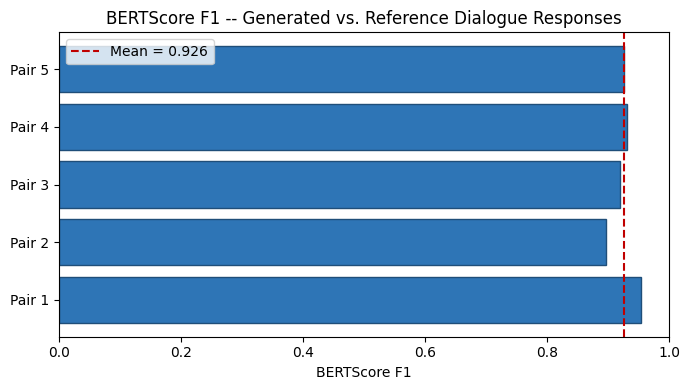


Interpretation:
  BERTScore F1 > 0.90 typically indicates highly similar responses.
  F1 in the 0.85-0.90 range indicates semantically related but not identical responses.
  F1 < 0.85 suggests meaningfully different content.


In [30]:
# Visualise the BERTScore F1 distribution across the evaluation set
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(range(len(eval_pairs)), F1.numpy(), color="#2E75B6", edgecolor="#1F4E79")
ax.set_yticks(range(len(eval_pairs)))
ax.set_yticklabels([f"Pair {i+1}" for i in range(len(eval_pairs))])
ax.set_xlabel("BERTScore F1")
ax.set_title("BERTScore F1 -- Generated vs. Reference Dialogue Responses")
ax.axvline(F1.mean().item(), color="#C00000", linestyle="--", label=f"Mean = {F1.mean().item():.3f}")
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("bertscore_dialogue.png", dpi=150)
plt.show()

print()
print("Interpretation:")
print("  BERTScore F1 > 0.90 typically indicates highly similar responses.")
print("  F1 in the 0.85-0.90 range indicates semantically related but not identical responses.")
print("  F1 < 0.85 suggests meaningfully different content.")


In [31]:
# Closing summary of all Day 25 components
print("Day 25 -- Chatbots and Dialogue Systems: Summary of Results")
print("=" * 65)
print()
print("Section 2: Intent Classification")
print(f"  Zero-shot NLI (demo intents)     -- qualitative, see output above")
print(f"  BERT fine-tuned (BANKING77/20)   -- see training output above")
print()
print("Section 3: Slot Filling (BIO labelling on MultiNERD)")
print(f"  BERT token classifier            -- see training output above")
print()
print("Section 4: Retrieval-Based Response Selection")
print(f"  SBERT + FAISS (bi-encoder)       -- qualitative, see output above")
print()
print("Section 5: Generative Dialogue")
print(f"  DialoGPT-medium                  -- qualitative, see output above")
print()
print("Section 6: Evaluation")
print(f"  BERTScore F1 (5 eval pairs)      -- {F1.mean().item():.4f} mean F1")


Day 25 -- Chatbots and Dialogue Systems: Summary of Results

Section 2: Intent Classification
  Zero-shot NLI (demo intents)     -- qualitative, see output above
  BERT fine-tuned (BANKING77/20)   -- see training output above

Section 3: Slot Filling (BIO labelling on MultiNERD)
  BERT token classifier            -- see training output above

Section 4: Retrieval-Based Response Selection
  SBERT + FAISS (bi-encoder)       -- qualitative, see output above

Section 5: Generative Dialogue
  DialoGPT-medium                  -- qualitative, see output above

Section 6: Evaluation
  BERTScore F1 (5 eval pairs)      -- 0.9261 mean F1
